In [ ]:
from dataLoader_multithread import xenium_data_load_multithreaded

data_dir = "/home/ailab/caohao/AdaDiss/data/"
sample_info_file = "samples.txt"  # 样本信息文件路径
scRNA_file = "Human_Lung_scRNA.h5ad"

/home/ailab/miniconda3/envs/AdaDiss/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("开始加载数据...")
try:
    # 调用多线程函数（即使只有一个样本也能工作）
    xenium_data = xenium_data_load_multithreaded(
        data_dir=data_dir,
        sample_info=sample_info_file,
        max_workers=4,  # 并发线程数
        n_jobs_per_sample=4  # 每个样本内部的并行数
    )
    
    print("✅ 数据加载成功！")
    
    # 查看数据基本信息
    if xenium_data is not None:
        table = xenium_data.tables['table']
        print(f"\n数据统计:")
        print(f"  - 细胞数量: {len(table.obs)}")
        print(f"  - 基因数量: {len(table.var)}")
        print(f"  - 样本名称: {table.obs['sample'].unique()}")
        print(f"  - 分组信息: {table.obs['group'].unique()}")
        print(f"  - 可用形状: {list(xenium_data.shapes.keys())}")
        
except FileNotFoundError:
    print(f"❌ 错误：找不到文件 {sample_info_file}")
    print("请先创建 samples.txt 文件")
except Exception as e:
    print(f"❌ 加载失败: {e}")

开始加载数据...
共发现 1 个样本
开始读取样本: Human_Prostate


/home/ailab/miniconda3/envs/AdaDiss/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              
✅ 完成读取样本: Human_Prostate
成功读取 1/1 个样本
正在合并样本...
✅ 成功关联 1 个细胞边界
✅ 数据处理完成，共 193000 个细胞
✅ 数据加载成功！

数据统计:
  - 细胞数量: 193000
  - 基因数量: 5006
  - 样本名称: ['Human_Prostate']
  - 分组信息: ['First']
  - 可用形状: ['nucleus_boundaries-Human_Prostate', 'cell_boundaries-Human_Prostate', 'cell_circles-Human_Prostate']


/home/ailab/miniconda3/envs/AdaDiss/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: cell_boundaries` to categorical dtype.
  convert_region_column_to_categorical(table)


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from spatialdata import SpatialData

# 提取AnnData表
adata_sp = xenium_data.tables['table']
print(adata_sp)

AnnData object with n_obs × n_vars = 193000 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'group', 'cell_boundaries'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


In [ ]:
# 查看obs的列名
print(adata_sp.obs.columns)

# 查看obsm的键
print(adata_sp.obsm.keys())

# 如果obsm中有'spatial'，则提取坐标
if 'spatial' in adata_sp.obsm:
    coords = adata_sp.obsm['spatial']
    print("坐标形状:", coords.shape)
else:
    # 如果没有，需要从shapes中计算质心，稍后处理
    print("obsm中没有'spatial'，需要从shapes提取")

Index(['cell_id', 'transcript_counts', 'control_probe_counts',
       'genomic_control_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count',
       'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample',
       'group', 'cell_boundaries'],
      dtype='object')
KeysView(AxisArrays with keys: spatial)
坐标形状: (193000, 2)


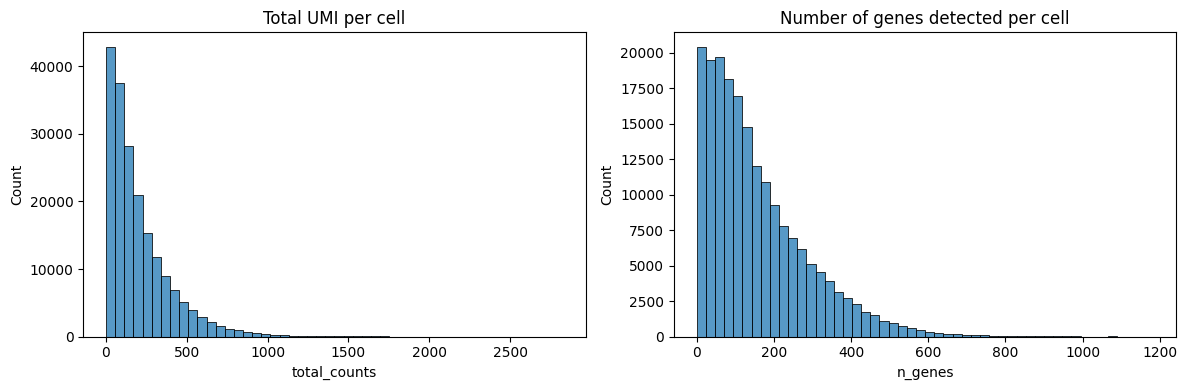

In [ ]:
# 计算每个细胞的总UMI数
adata_sp.obs['total_counts'] = adata_sp.X.sum(axis=1).A1 if hasattr(adata_sp.X, 'A') else adata_sp.X.sum(axis=1)

# 计算每个细胞检测到的基因数（非零基因数）
adata_sp.obs['n_genes'] = (adata_sp.X > 0).sum(axis=1).A1 if hasattr(adata_sp.X, 'A') else (adata_sp.X > 0).sum(axis=1)

# 查看分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adata_sp.obs['total_counts'], bins=50, ax=axes[0])
axes[0].set_title('Total UMI per cell')
sns.histplot(adata_sp.obs['n_genes'], bins=50, ax=axes[1])
axes[1].set_title('Number of genes detected per cell')
plt.tight_layout()
plt.show()

In [ ]:
# 例如过滤总UMI < 100 或 基因数 < 50 的细胞
sc.pp.filter_cells(adata_sp, min_counts=100)
sc.pp.filter_cells(adata_sp, min_genes=50)

In [ ]:
# 标准化到每个细胞总UMI为1e4（用于后续高变基因选择）
sc.pp.normalize_total(adata_sp, target_sum=1e4)
sc.pp.log1p(adata_sp)

# 选择高变基因
sc.pp.highly_variable_genes(adata_sp, n_top_genes=2000, flavor='seurat_v3', batch_key='sample' if 'sample' in adata_sp.obs else None)
print(f"高变基因数量: {adata_sp.var['highly_variable'].sum()}")

# 保存高变基因标记到var
adata_sp.var['highly_variable'] = adata_sp.var['highly_variable']

# 可选：将adata过滤为只保留高变基因（后续PCA等使用）
adata_hvg = adata_sp[:, adata_sp.var['highly_variable']].copy()

/home/ailab/miniconda3/envs/AdaDiss/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


高变基因数量: 2000


In [ ]:
# 对高变基因数据进行PCA
sc.tl.pca(adata_hvg, svd_solver='arpack', n_comps=50)

# 将PCA结果存入原始adata的obsm中，方便后续使用
adata_sp.obsm['X_pca'] = adata_hvg.obsm['X_pca']

# 正确打印方差解释率（从adata_hvg中读取）
print(f"PCA explained variance ratio: {adata_hvg.uns['pca']['variance_ratio'][:5]}")

# 可选：将PCA的方差解释率也复制到原始adata中，供以后参考
adata_sp.uns['pca'] = adata_hvg.uns['pca'].copy()

PCA explained variance ratio: [0.06482447 0.01631661 0.01412469 0.00979993 0.00946695]


In [ ]:
# 读取 scRNAs
adata_sc = sc.read_h5ad(f"{data_dir}{scRNA_file}")

print(adata_sc)
print("scRNA obs:", adata_sc.obs.columns)
print("scRNA var:", adata_sc.var_names[:10])

# 确认 cell type 标签列名
print(adata_sc.obs["cell_type"].value_counts())

In [ ]:
# scRNA 预处理
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)

# 只保留高变基因（可选）
sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000, flavor="seurat_v3")
adata_sc = adata_sc[:, adata_sc.var["highly_variable"]].copy()

# PCA
sc.tl.pca(adata_sc, n_comps=50)

In [ ]:
# ===== 新代码块 C：找共同基因 =====
common_genes = adata_sc.var_names.intersection(adata_sp.var_names)

print("共同基因数量:", len(common_genes))

# 只保留共同基因
adata_sc_sub = adata_sc[:, common_genes].copy()
adata_sp_sub = adata_sp[:, common_genes].copy()

print("scRNA shape:", adata_sc_sub.shape)
print("Xenium shape:", adata_sp_sub.shape)

In [ ]:
# ===== 新代码块 D：训练分类器 =====
from sklearn.linear_model import LogisticRegression

X_train = adata_sc_sub.X
y_train = adata_sc_sub.obs["cell_type"]

clf = LogisticRegression(max_iter=1000, n_jobs=8)
clf.fit(X_train, y_train)

print("分类器训练完成")

In [ ]:
# ===== 新代码块 E：预测 Xenium =====
X_test = adata_sp_sub.X

adata_sp.obs["pseudo_cell_type"] = clf.predict(X_test)

print("Pseudo cell type 分布:")
print(adata_sp.obs["pseudo_cell_type"].value_counts())

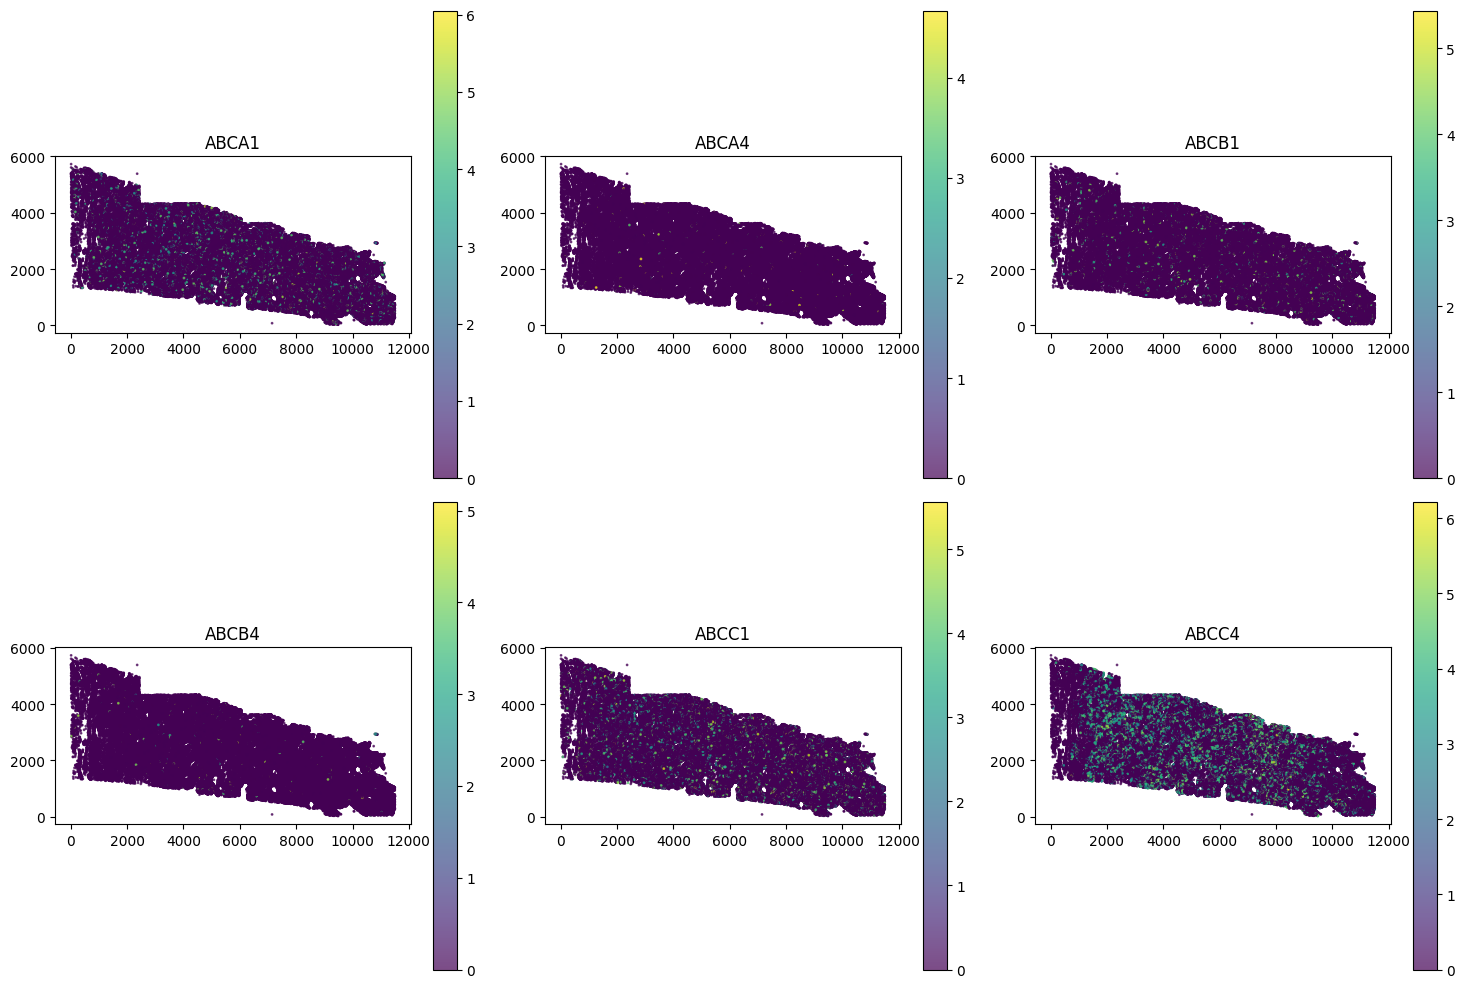

In [ ]:
# 获取空间坐标（确保存在）
if 'spatial' in adata_sp.obsm:
    coords = adata_sp.obsm['spatial']
    # 随机选择几个基因（或前几个高变基因）
    top_genes = adata_sp.var_names[adata_sp.var['highly_variable']][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, gene in zip(axes.ravel(), top_genes):
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=adata_sp[:, gene].X.toarray().flatten() if hasattr(adata_sp.X, 'toarray') else adata_sp[:, gene].X.flatten(),
                        s=1, cmap='viridis', alpha=0.7)
        ax.set_title(gene)
        ax.set_aspect('equal')
        plt.colorbar(sc, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("没有空间坐标，无法可视化")

In [ ]:
# ===== 新代码块 F：可视化 pseudo label =====
if "spatial" in adata.obsm:
    coords = adata.obsm["spatial"]
    categories = adata.obs["pseudo_cell_type"].astype("category")
    colors = plt.cm.tab20(np.linspace(0, 1, len(categories.cat.categories)))
    color_map = {cat: colors[i] for i, cat in enumerate(categories.cat.categories)}
    cell_colors = categories.map(color_map).tolist()

    plt.figure(figsize=(10, 10))
    plt.scatter(coords[:, 0], coords[:, 1], c=cell_colors, s=1, alpha=0.6)
    plt.title("Pseudo Cell Types spatial distribution")

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color_map[cat],
            markersize=8,
            label=cat,
        )
        for cat in categories.cat.categories
    ]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

没有细胞类型标签，后续可能需要从外部数据注释或进行无监督聚类。


In [ ]:
adata_sp.write('preprocessed_data.h5ad')
print("预处理数据已保存到 preprocessed_data.h5ad")

预处理数据已保存到 preprocessed_data.h5ad
